# Reproducing the CRC multicellular factor analysis (MOFACell)

This notebook reproduces, as closely as possible with MINA, the multicellular
factor analysis of the Hamburg colorectal-cancer (CRC) MIBI study
(`notebooks/multicellular/MOFACell.ipynb` in the study repository). It starts
from the **precomputed** feature object the study assembled,
`celltype_features_with_functional_markers.h5mu`, so the only modelling choices
that differ from the original are those of the factor-decomposition engine.

The original ran **MuVI** with `nmf=False` (a linear model, *without* enforced
non-negativity). MINA performs the decomposition with
[MOFA-FLEX](https://github.com/bioFAM/mofaflex); we use a Normal likelihood with
a spike-and-slab weight prior, which is the matching linear, non-negativity-free
setup.

!!! note "About the data"
    This example expects the precomputed
    `celltype_features_with_functional_markers.h5mu` (8 cell-type views over
    field-of-view samples, each carrying cell-type abundance, metabolic and
    functional markers, morphology, and MISTy spatial lineage-interaction
    features, plus a `Stage` covariate). Set `DATA_DIR` below. It is not shipped
    with MINA.

!!! tip "Requirements"
    `pip install "mina[spatial]"` and a working `mofaflex` install.

In [15]:
from pathlib import Path

import numpy as np
import pandas as pd
import mudata as md
import matplotlib.pyplot as plt

import mofaflex as mf
import mina

DATA_DIR = Path("/Users/lvulliard/Documents/Projects/MIBI-Analysis_Hamburg_CRC_TMA_2024/data")
features = md.read(DATA_DIR / "celltype_features_with_functional_markers.h5mu")
features

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:571: UserWarning: Cannot join columns with the same name because var_names are intersecting.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


MuData object with n_obs × n_vars = 423 × 308
  obs:	'Stage'
  8 modalities
    Other_immune_cell:	423 x 40
    Fibroblast:	423 x 40
    Macrophage:	423 x 39
    CD4_lymphocyte:	423 x 33
    Epithelial_cell:	423 x 49
    Endothelial_cell:	423 x 38
    Monocyte:	423 x 38
    Cytotoxic_lymphocyte:	423 x 31

## 1. The precomputed multi-view object

Samples are fields of view (FOVs); the eight modalities are cell-type lineages.
Each view stacks the same feature blocks: cell-type **abundance**
(`proportion`), **metabolic** and **functional** markers, **morphology**, and
the **MISTy** spatial lineage-interaction features. Clinical tumour stage is in
`features.obs["Stage"]`.

In [16]:
anndata_dict = {view: features[view].copy() for view in features.mod}

metadata = features.obs.copy()
metadata.index = metadata.index.astype(str)
metadata["sample_id"] = metadata.index

{view: ad.shape for view, ad in anndata_dict.items()}

{'Other_immune_cell': (423, 40),
 'Fibroblast': (423, 40),
 'Macrophage': (423, 39),
 'CD4_lymphocyte': (423, 33),
 'Epithelial_cell': (423, 49),
 'Endothelial_cell': (423, 38),
 'Monocyte': (423, 38),
 'Cytotoxic_lymphocyte': (423, 31)}

## 2. Preprocessing

MOFACell centred and scaled every feature within each modality. MINA reproduces
this exactly with `norm_log(method="zscore")` (missing values are kept as NaN
and handled by the model). Features are then prefixed with their view.

In [17]:
mina.up.norm_log(anndata_dict, method="zscore")
mina.up.utils.append_view_to_var(anndata_dict)

Per-view z-score normalization complete for all AnnData objects.


## 3. Factor decomposition (linear, non-negativity-free)

Ten factors, matching the original MuVI `n_factors=10`, `nmf=False` run. The
spike-and-slab weight prior with a Normal likelihood is the linear,
non-negativity-free MOFA-FLEX equivalent.

In [18]:
mdata_model = md.MuData(anndata_dict)

# Good match to MuVI run
model = mf.terms.MofaFlex(
    n_factors=10,
    factor_prior="Normal",
    weight_prior="Horseshoe",
    nonnegative_factors=False,
    nonnegative_weights=False,
)

model.fit(
    mdata_model,
    seed=0, # 9 and 11 have 0.402 reconstruction R2
    max_epochs=10000,
    batch_size=0,
    n_particles=1,
    save_path=False,
    plot_data_overview=False,
)

# More default options
# model = mf.terms.MofaFlex(
#     n_factors=10,
# )

# model.fit(
#     mdata_model,
#     seed=20, # 8 and 20 have 0.400 reconstruction R2
#     save_path=False,
#     plot_data_overview=False,
# )

amodel = mina.down.model_to_anndata(
    anndata_dict=anndata_dict, metadata=metadata, model=model
)
amodel

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1275: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1403: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymor

AnnData object with n_obs × n_vars = 423 × 10
    obs: 'Stage', 'sample_id', 'Other_immune_cell_n_cells', 'Fibroblast_n_cells', 'Macrophage_n_cells', 'CD4_lymphocyte_n_cells', 'Epithelial_cell_n_cells', 'Endothelial_cell_n_cells', 'Monocyte_n_cells', 'Cytotoxic_lymphocyte_n_cells'
    var: 'CD4_lymphocyte:group_1', 'Cytotoxic_lymphocyte:group_1', 'Endothelial_cell:group_1', 'Epithelial_cell:group_1', 'Fibroblast:group_1', 'Macrophage:group_1', 'Monocyte:group_1', 'Other_immune_cell:group_1'
    uns: 'gene_loadings_columns', 'Other_immune_cell_columns', 'Fibroblast_columns', 'Macrophage_columns', 'CD4_lymphocyte_columns', 'Epithelial_cell_columns', 'Endothelial_cell_columns', 'Monocyte_columns', 'Cytotoxic_lymphocyte_columns'
    obsm: 'Other_immune_cell', 'Fibroblast', 'Macrophage', 'CD4_lymphocyte', 'Epithelial_cell', 'Endothelial_cell', 'Monocyte', 'Cytotoxic_lymphocyte'
    varm: 'gene_loadings'

## 4. Variance explained and reconstruction

A macro-R² around 0.4 reproduces the original report.

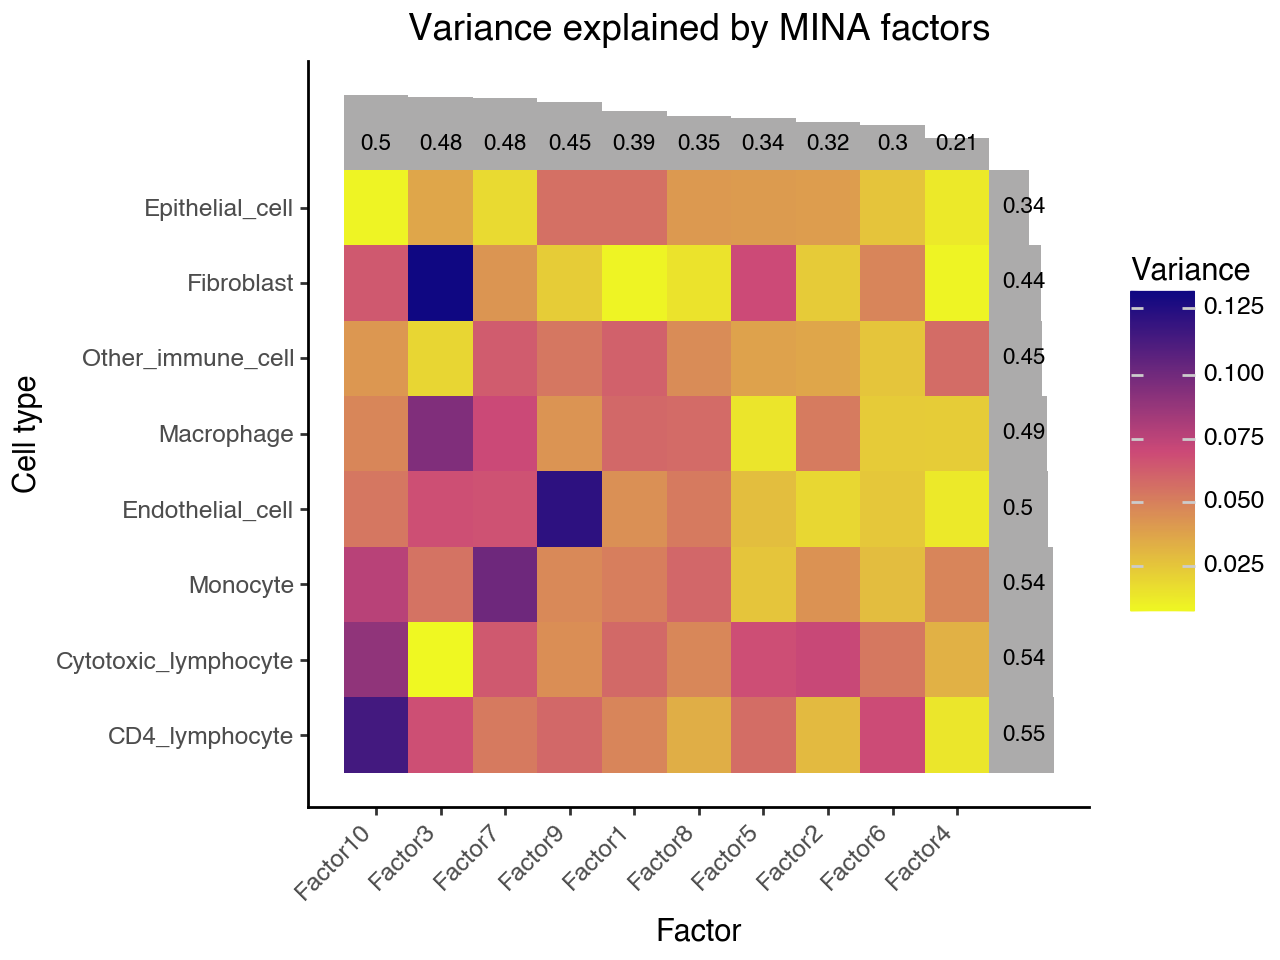

In [19]:
variance_df = mina.down.variance_by_view_info(amodel)
mina.pl.plot_variance_by_view(variance_df)

In [20]:
reconstruction = mina.down.reconstruction_info(amodel)
print("Macro R2:", round(reconstruction["macro"]["R2"], 3))

Macro R2: 0.395


In [21]:
reconstruction

{'by_view':                    view         R        R2
 0     Other_immune_cell  0.610462  0.372663
 1            Fibroblast  0.614488  0.377596
 2            Macrophage  0.629413  0.396160
 3        CD4_lymphocyte  0.657632  0.432480
 4       Epithelial_cell  0.558416  0.311829
 5      Endothelial_cell  0.641618  0.411674
 6              Monocyte  0.653607  0.427201
 7  Cytotoxic_lymphocyte  0.658970  0.434242,
 'macro': {'R': np.float64(0.6280756914429628),
  'R2': np.float64(0.39548061597486883)}}

## 5. Variance explained per feature class

As in the original, metabolic and functional markers carry most of the captured
variance. The spatial feature list is everything that is not abundance,
metabolism, function or morphology (i.e. the MISTy interaction features).

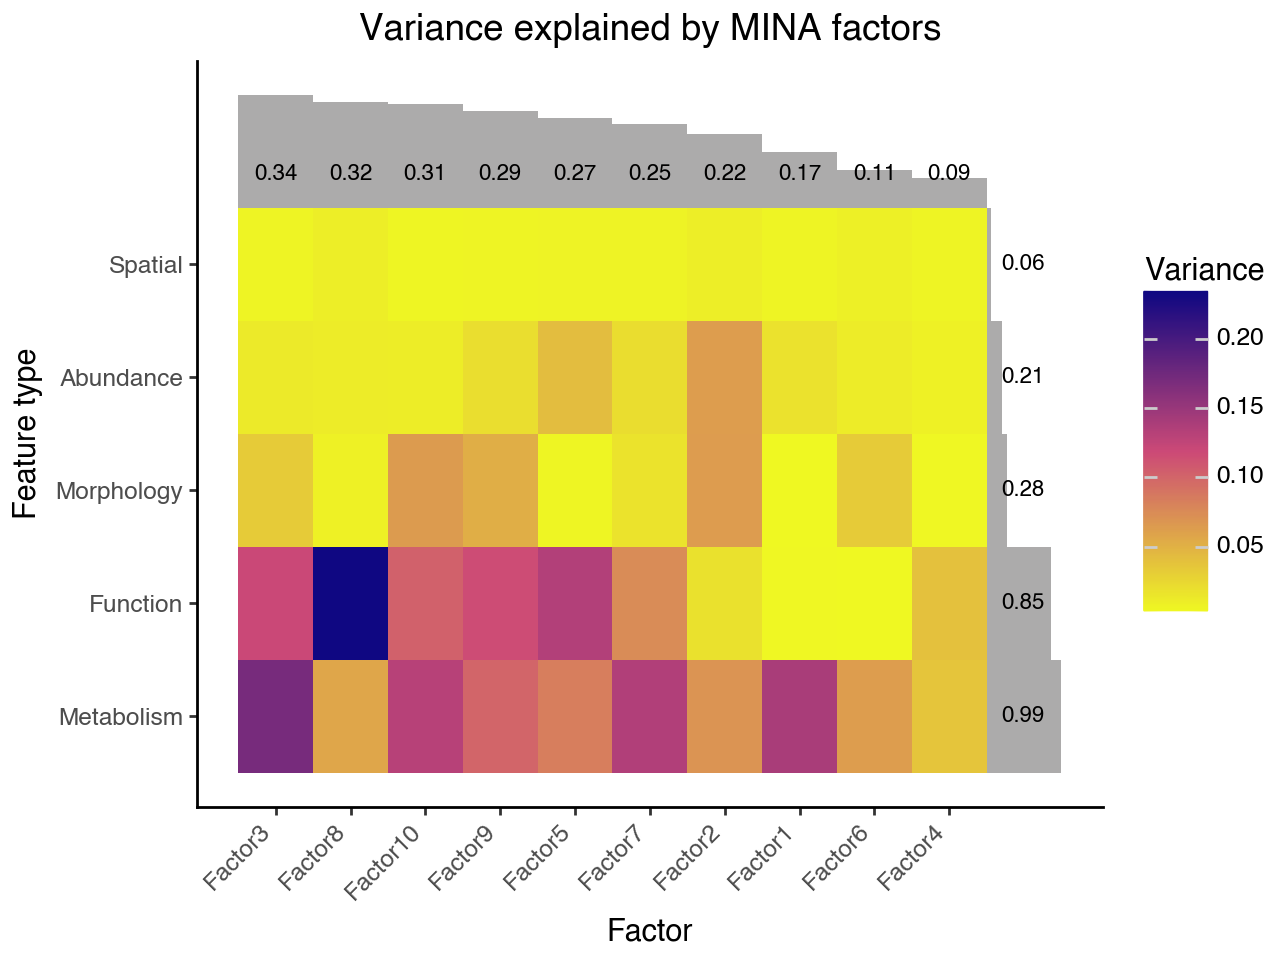

In [22]:
metab = ["CA9", "CD98", "CytC", "MCT1", "ASCT2", "LDH", "GS", "GLS",
         "ATP5A", "CS", "PKM2", "GLUT1", "ARG1", "CPT1A", "Ki67"]
func = ["PD1", "PDL1", "STING1", "MSH2", "MSH6"]
morpho = ["eccentricity", "perimeter", "area"]
morpho = morpho + [f"{m}_std" for m in morpho]

all_features = set()
for view in amodel.obsm:
    all_features |= {str(c) for c in amodel.uns[f"{view}_columns"]}
spatial = sorted(all_features - {"proportion", *metab, *func, *morpho})

feature_type_map = {
    "Abundance": ["proportion"],
    "Metabolism": metab,
    "Function": func,
    "Morphology": morpho,
    "Spatial": spatial,
}
featureclass_df = mina.down.featureclass_variance_info(amodel, feature_type_map=feature_type_map)
mina.pl.plot_featureclass_variance(featureclass_df)

## 6. Reconstruction

Macro R2: 0.395


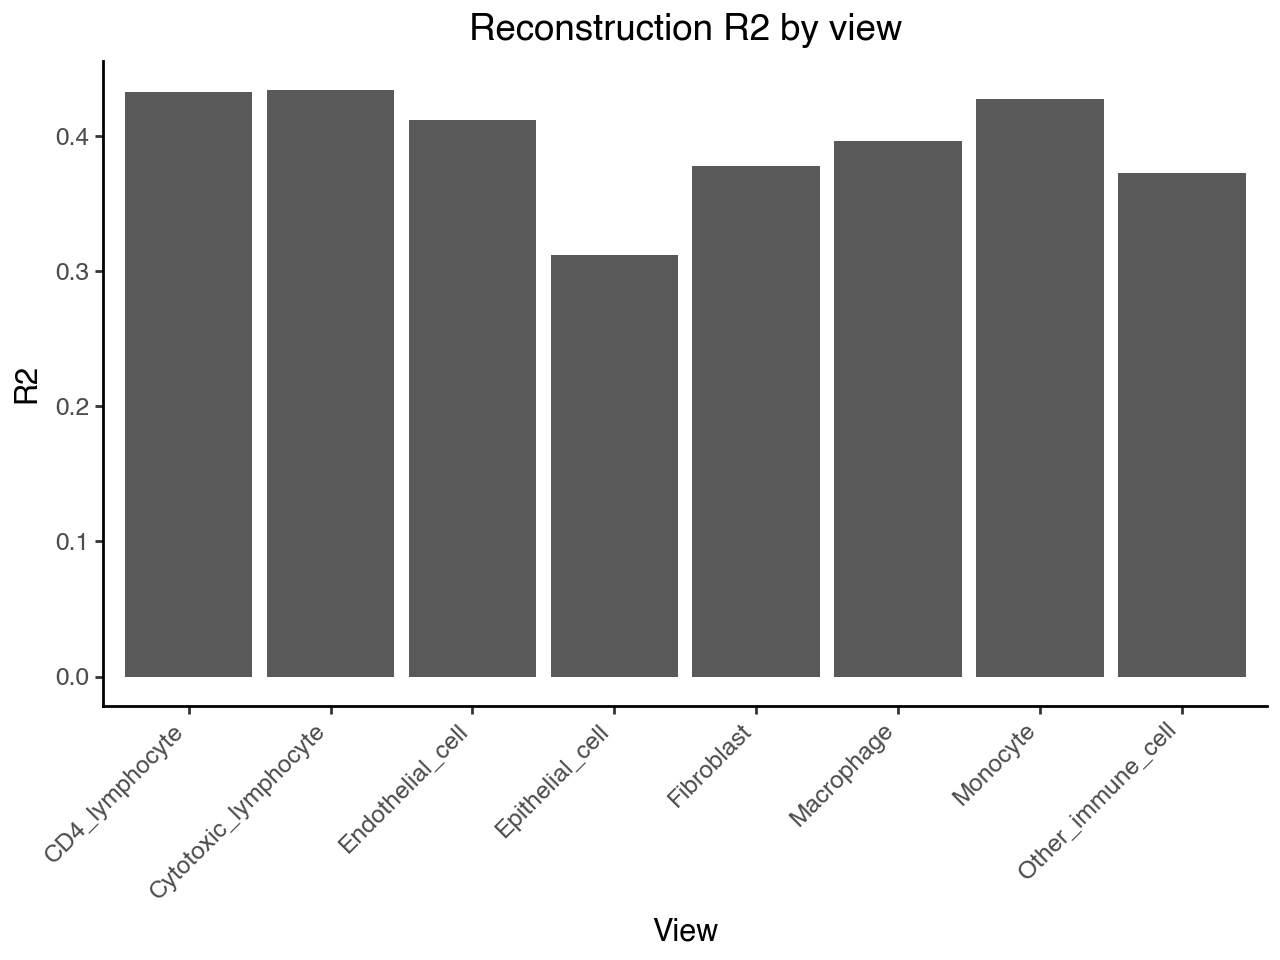

In [23]:
reconstruction = mina.down.reconstruction_info(amodel)
print("Macro R2:", round(reconstruction["macro"]["R2"], 3))
mina.pl.plot_reconstruction(reconstruction["by_view"])

## 7. Stage-associated factors

In [24]:
scores = mina.down.factor_scores_info(
    amodel, obs_keys=["Stage"]
)

pT_assoc = mina.down.kruskal_info(scores, group_col="Stage")
pT_assoc.head()

,factor,pvalue,pvalue_bonferroni
0,Factor7,0.000012,0.000115
1,Factor8,0.000440,0.004405
2,Factor1,0.000672,0.006717
3,Factor6,0.010273,0.102729
4,Factor4,0.011112,0.111123


/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/plotnine/positions/position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


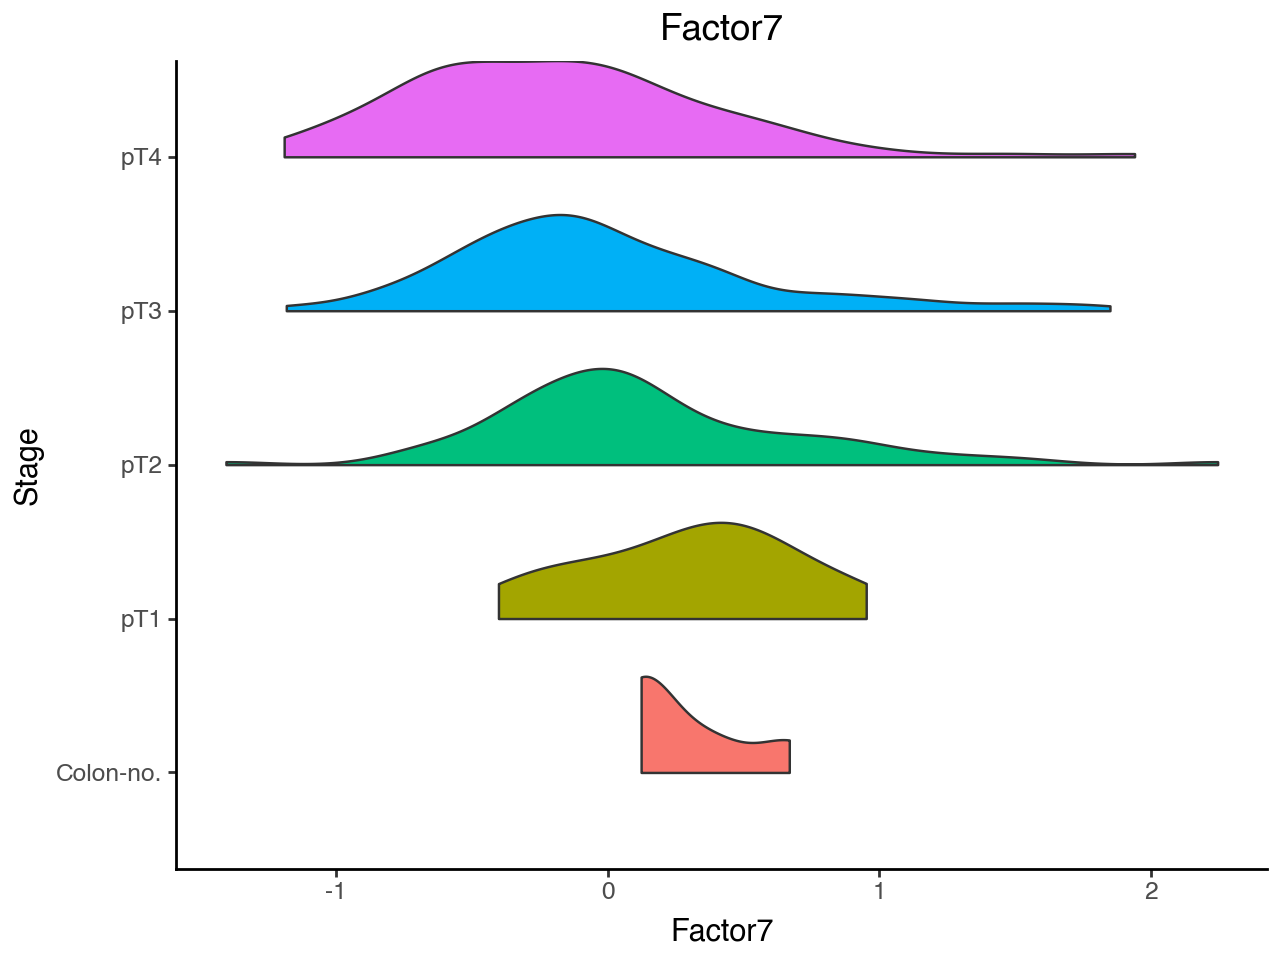

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/plotnine/positions/position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


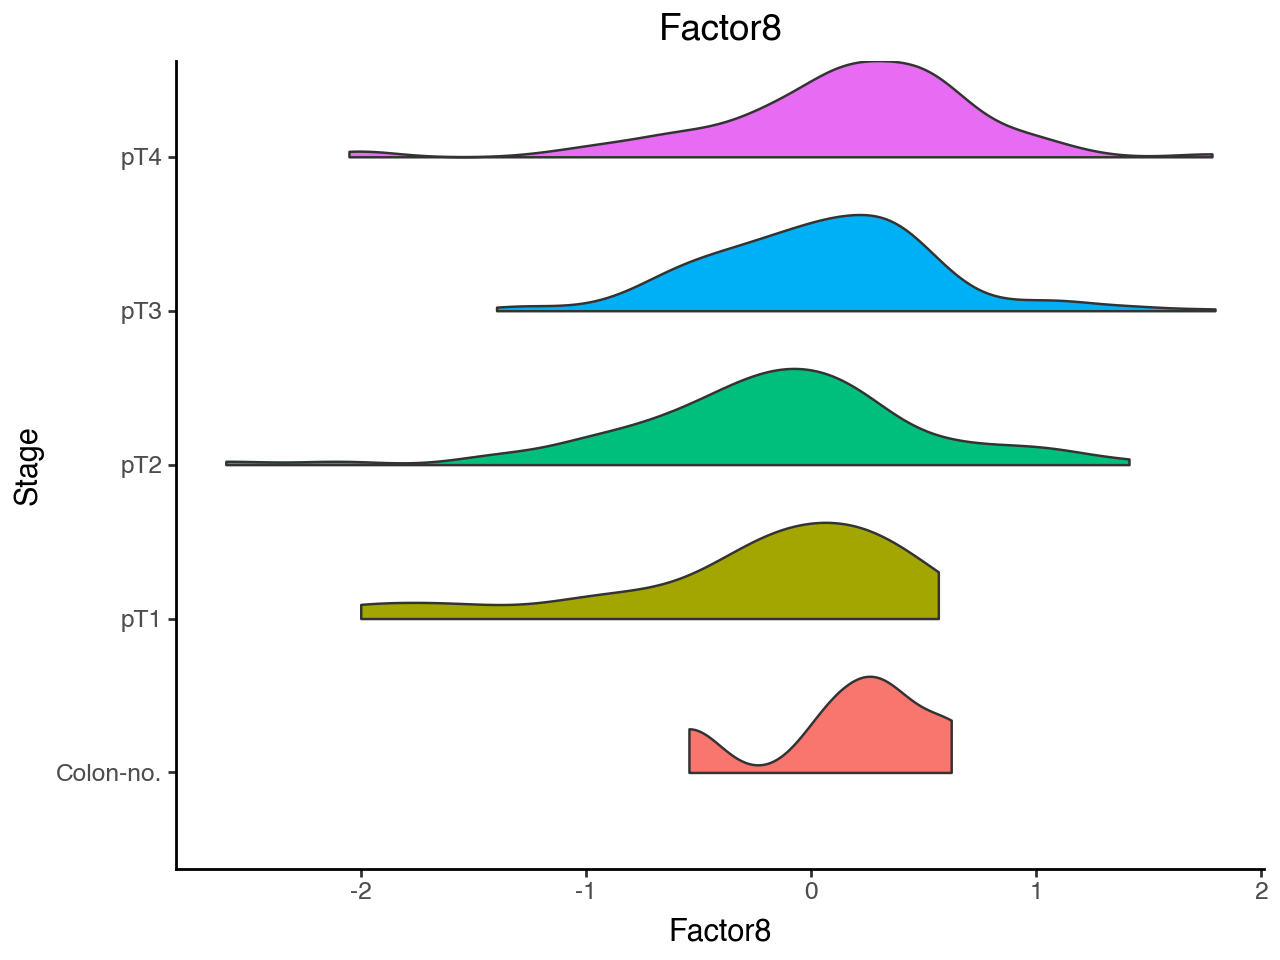

/Users/lvulliard/Documents/Tests/MINA/.venv/lib/python3.12/site-packages/plotnine/positions/position.py:232: PlotnineWarning: position_dodge requires non-overlapping x intervals


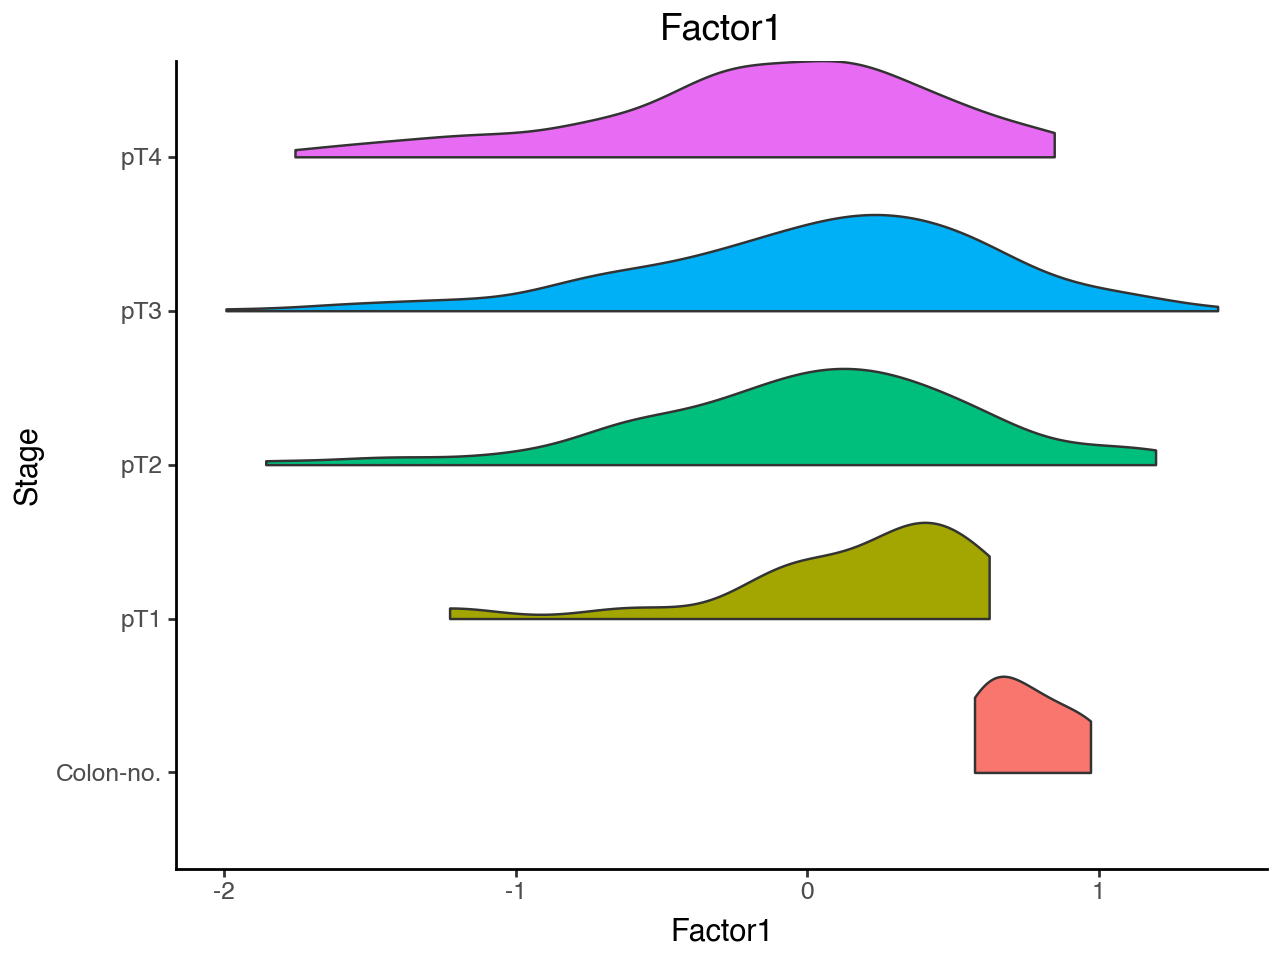

In [25]:
top_factors = pT_assoc.loc[pT_assoc["pvalue_bonferroni"] < 0.05]
for top_factor in top_factors["factor"]:
    gp = mina.pl.plot_factor_violin(scores, factor=top_factor, group_col="Stage")
    gp.show()

## 7. Stage separation in factor space (biplot)

Reproducing the BiplotFactors figure: the two leading stage-associated factors
with per-stage 2-SD confidence ellipses.

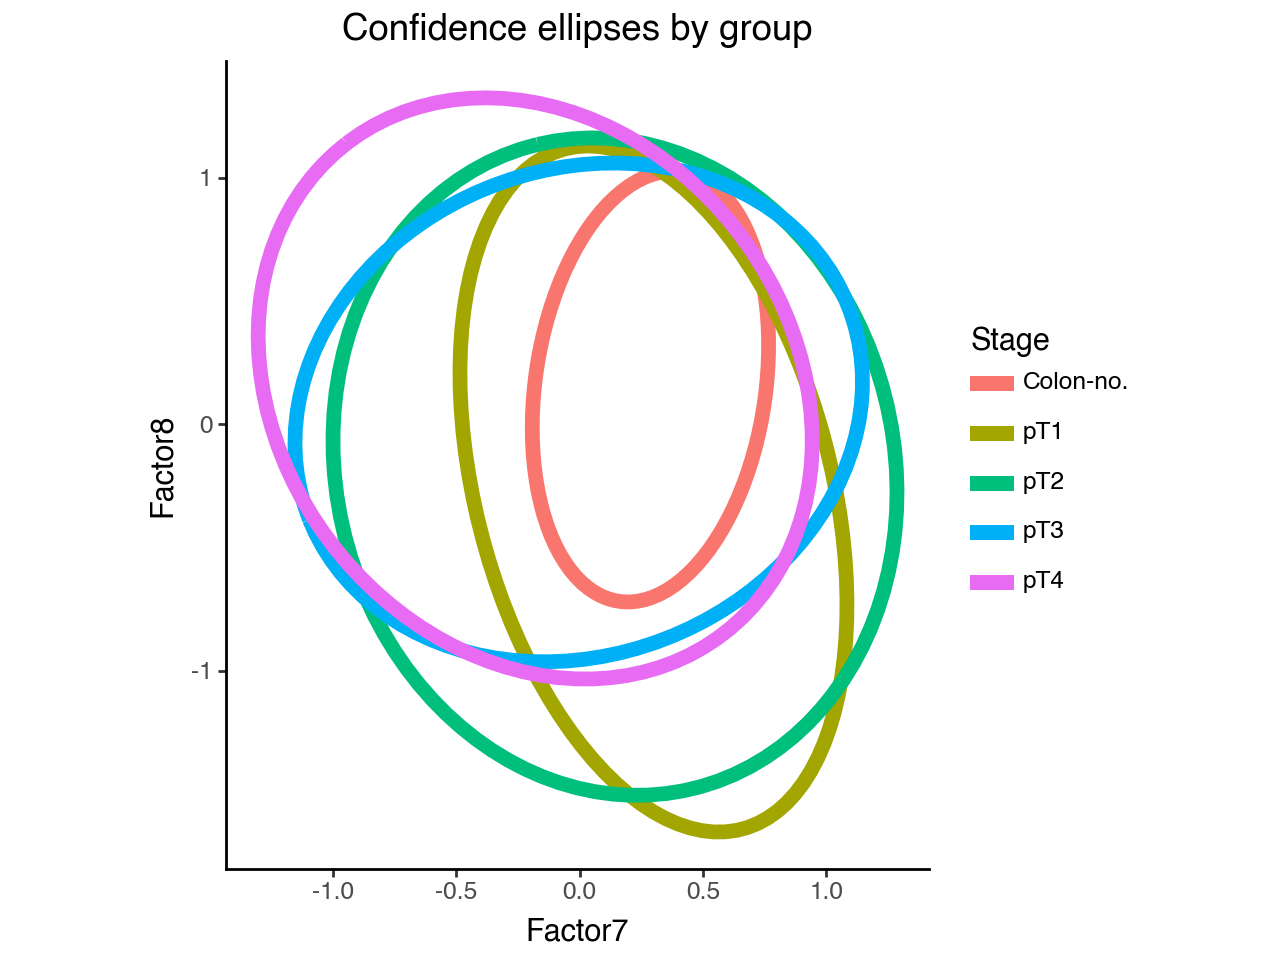

In [26]:
f_x, f_y = pT_assoc.iloc[0]["factor"], pT_assoc.iloc[1]["factor"]
ellipse_df = mina.down.confidence_ellipses_info(scores, x_factor=f_x, y_factor=f_y, group_col="Stage")
mina.pl.plot_confidence_ellipses(scores, ellipse_df, x_factor=f_x, y_factor=f_y, group_col="Stage")

## 8. Top loadings of a stage-associated factor

The features (and views) driving the leading stage-associated factor —
the MINA equivalent of the per-factor loading heatmaps in the original.

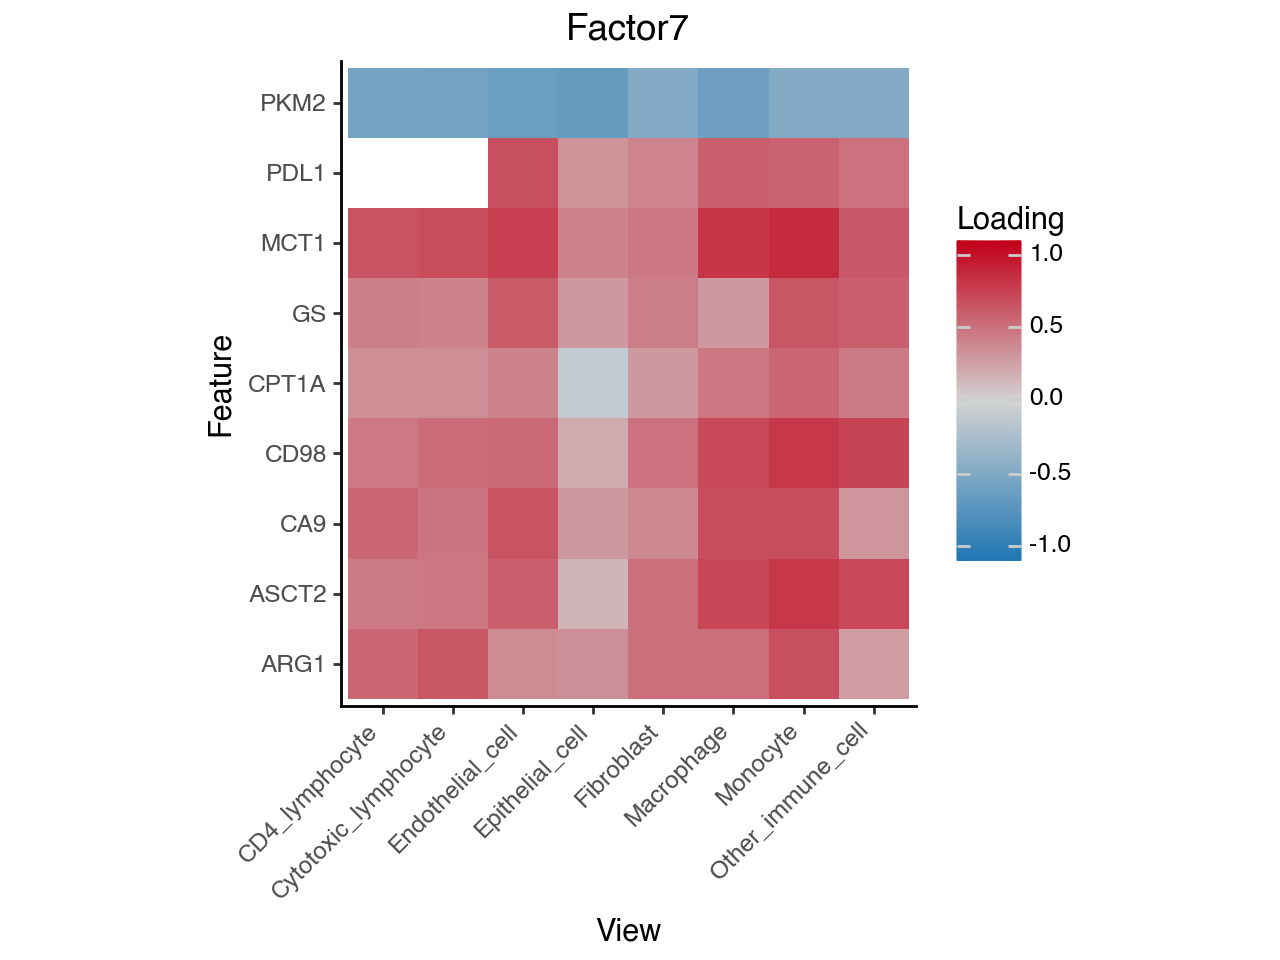

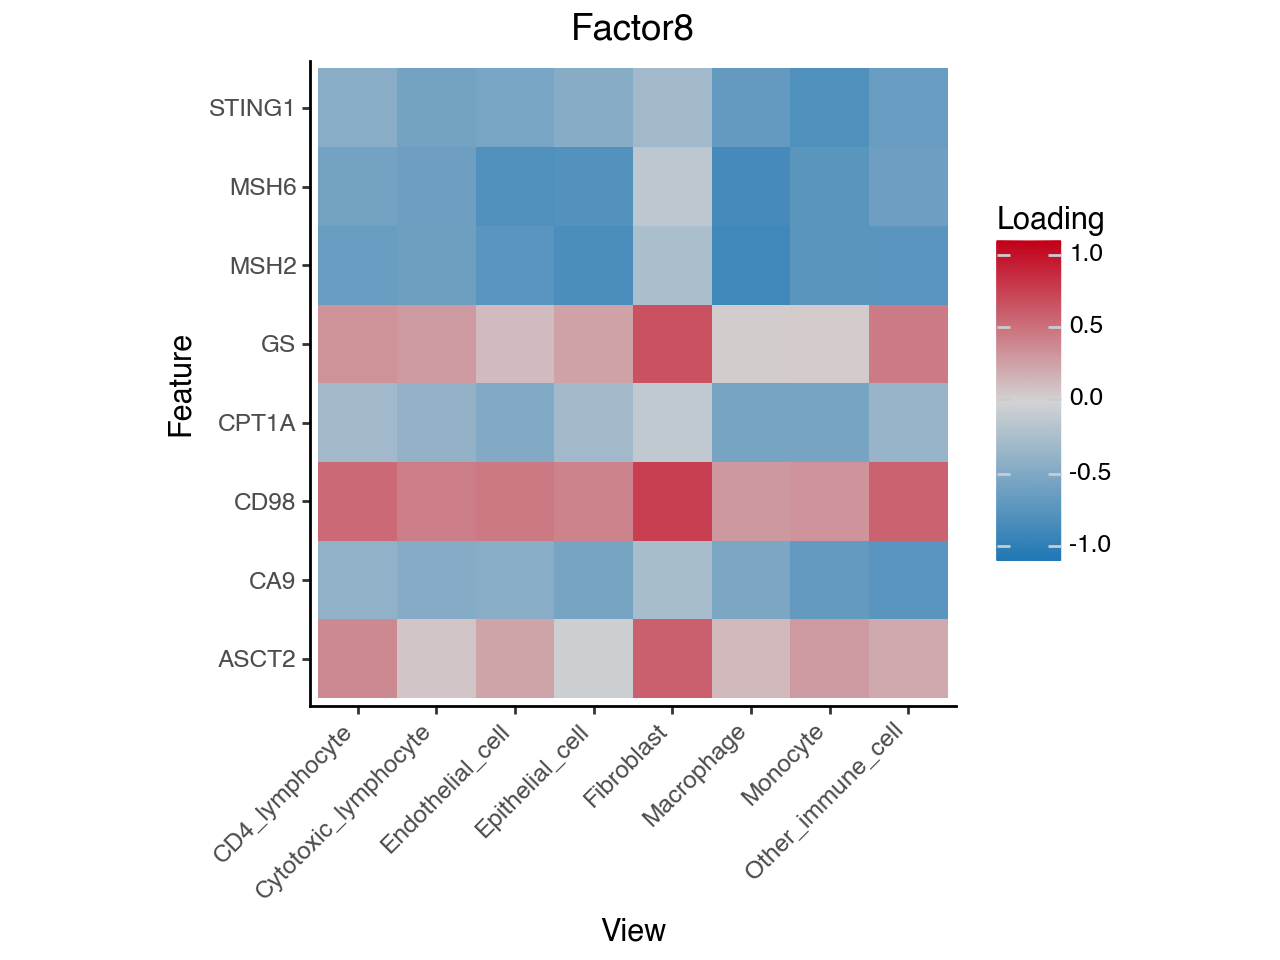

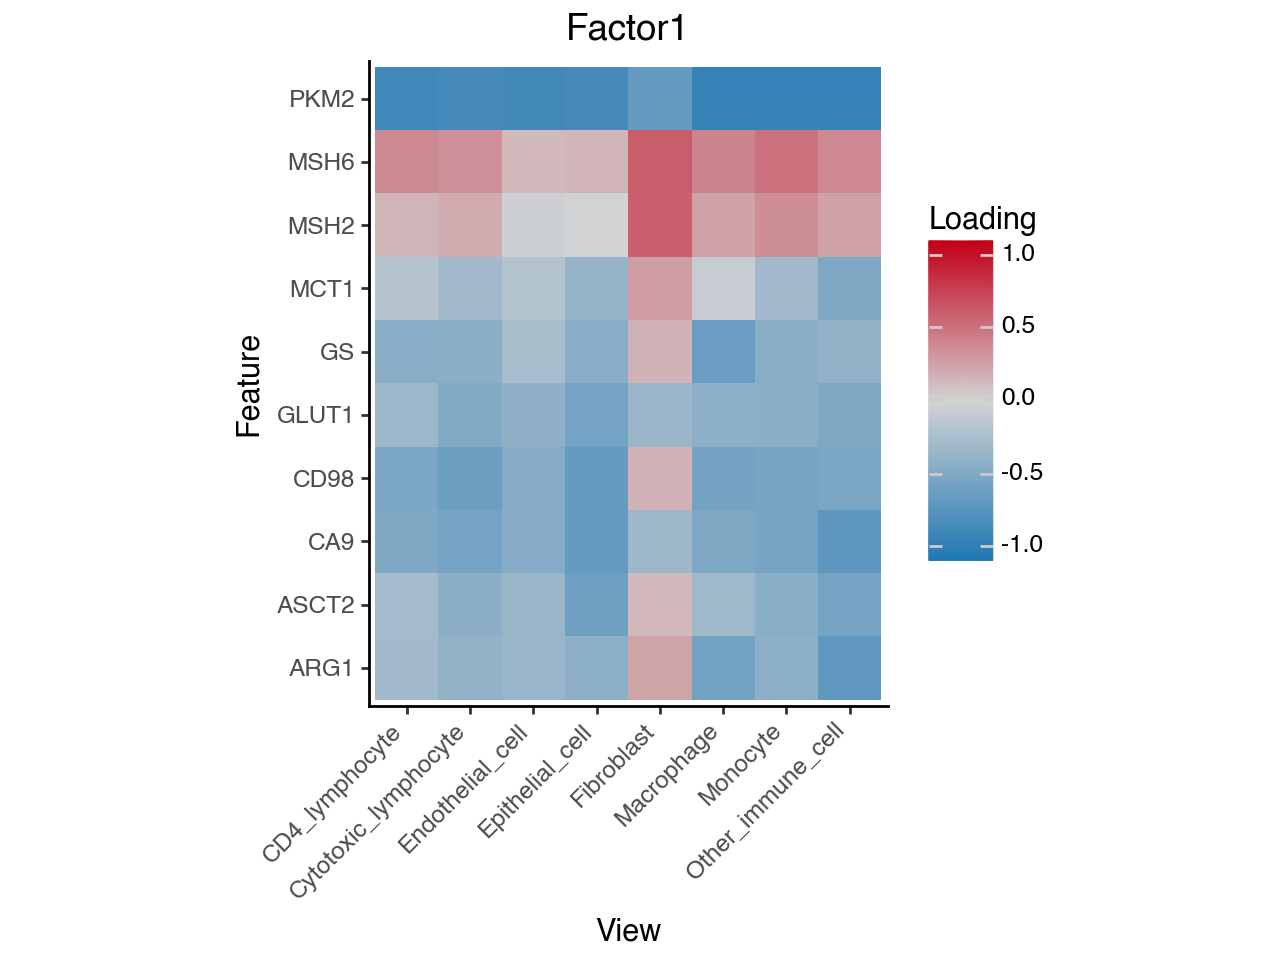

In [27]:
for top_factor in top_factors["factor"]:
    loadings = mina.down.variable_loadings_info(amodel)
    gp = mina.pl.plot_top_loadings_heatmap(loadings, factor=top_factor, top_n=30)
    gp.show()

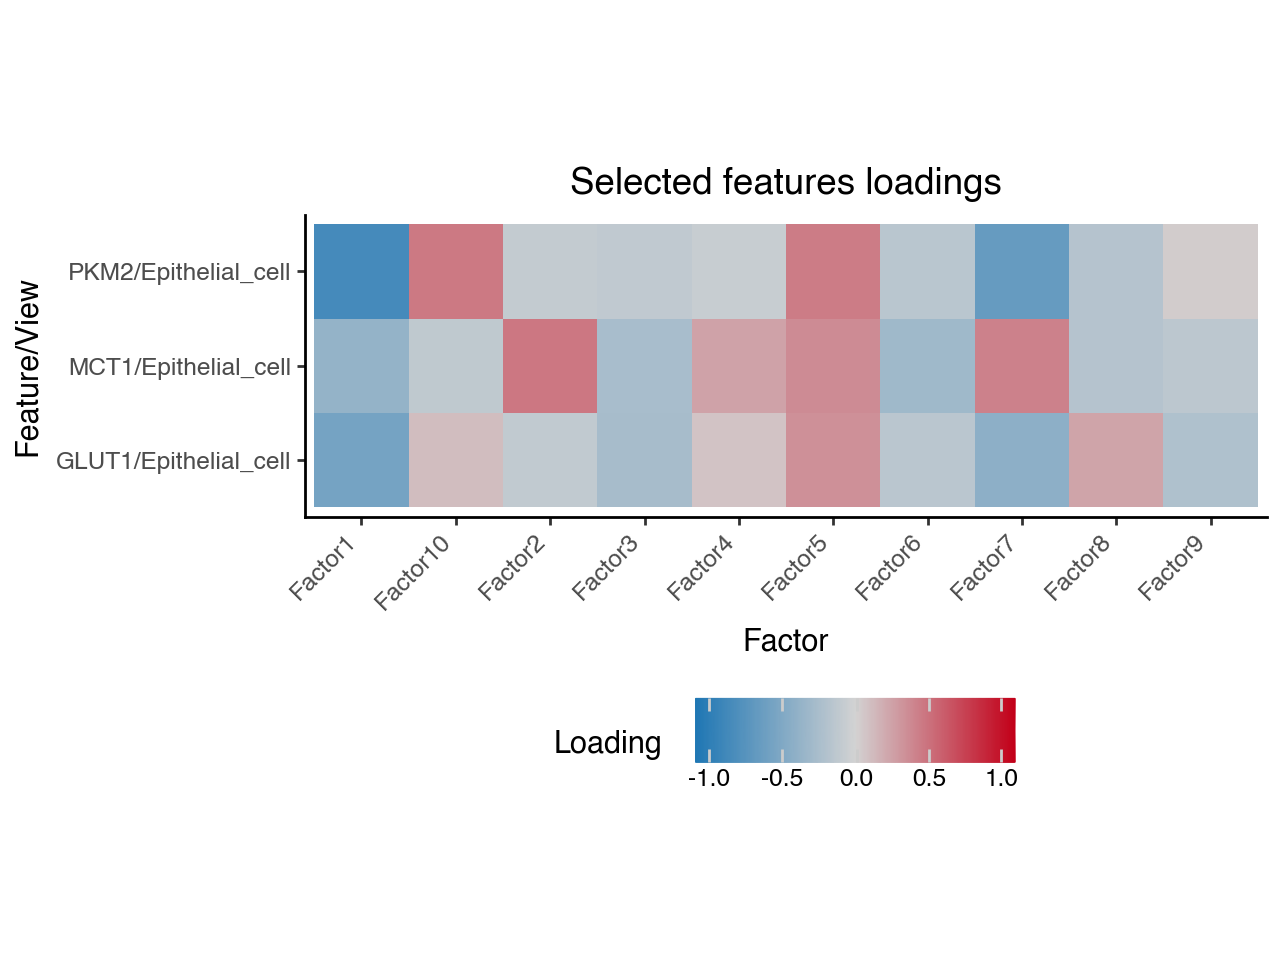

In [28]:
ft_to_display = ["GLUT1", "MCT1", "PKM2"]
selected_df = mina.down.selected_features_info(
    loadings,
    selections=[(ft, "Epithelial_cell") for ft in ft_to_display],
)
mina.pl.plot_selected_features(
    selected_df,
)

## Summary

Starting from the study's precomputed feature object, MINA reproduces the CRC
multicellular factor analysis: a ten-factor linear (non-negativity-free)
decomposition with macro-R² ≈ 0.4, dominated by metabolic and functional
variance, with several factors significantly associated with tumour stage and a
clear stage gradient in the leading factor biplot.

Because the decomposition engine differs from the original MuVI run, individual
factor numbers are not expected to match one-to-one; screen associations
programmatically (as above). The same `factor_scores_info` / `kruskal_info`
workflow extends directly to the study's other covariates such as nodal status
(pN) and microsatellite instability (MSI).